In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
import csv

In [ ]:
# Setting up the data structure
data = []

# A function that will filter my data so that I only have usable information
def to_float(value):
    try:
        return float(value)
    except:
        return None

with open("PSCompPars_2026(1485).csv", newline='') as file:
    for line in file:
        if not line.startswith("#"):  # finds the first non-metadata line
            header_line = line
            break

    reader = csv.DictReader(file, fieldnames=header_line.strip().split(","))

    for row in reader:
        temp = to_float(row["pl_eqt"])
        tperr = to_float(row["pl_eqterr1"])
        tnerr = to_float(row["pl_eqterr2"])
        radius = to_float(row["pl_radj"])
        rperr = to_float(row["pl_radjerr1"])
        rnerr = to_float(row["pl_radjerr2"])
        sma = to_float(row["pl_orbsmax"])
        smperr = to_float(row["pl_orbsmaxerr1"])
        smnerr = to_float(row["pl_orbsmaxerr2"])
        st_lum = to_float(row["st_lum"])
        slperr = to_float(row["st_lumerr1"])
        slnerr = to_float(row["st_lumerr2"])
        st_mass = to_float(row["st_mass"])
        smperr = to_float(row["st_masserr1"])
        smnerr = to_float(row["st_masserr2"])
        st_met = to_float(row["st_met"])
        smperr = to_float(row["st_meterr1"])
        smnerr = to_float(row["st_meterr2"])
        st_rad = to_float(row["st_rad"])
        srperr = to_float(row["st_raderr1"])
        srnerr = to_float(row["st_raderr2"])

        if None not in (temp, tperr, tnerr, radius, rperr, rnerr, sma, smperr, smnerr, st_lum, slperr, slnerr, st_mass, smperr, smnerr, st_met, smperr, smnerr, st_rad, srperr, srnerr):
            data.append({
                "pl_temp" : temp,
                "temp_plus" : tperr,
                "temp_minus" : tnerr,

                "pl_rad" : radius,
                "pl_rad_plus" : rperr,
                "pl_rad_minus" : rnerr,

                "sma" : sma,
                "sma_plus" : smperr,
                "sma_minus" : smnerr,

                "st_lum" : st_lum,
                "lum_plus" : slperr,
                "lum_minus" : slnerr,

                "st_mass" : st_mass,
                "mass_plus" : smperr,
                "mass_minus" : smnerr,

                "st_met" : st_met,
                "met_plus" : smperr,
                "met_minus" : smnerr,

                "st_rad" : st_rad,
                "st_rad_plus" : srperr,
                "st_rad_minus" : srnerr
            })

        for d in data:
            if d["st_lum"] / (4 * np.pi * d["sma"] ** 2) < -1000:
                data.remove(d)


## Observed Data

temps = [d["pl_temp"] for d in data]
temps_plus = [d["temp_plus"] for d in data]
temps_minus = [abs(d["temp_minus"]) for d in data]

radii = [d["pl_rad"] for d in data]
radii_plus = [d["pl_rad_plus"] for d in data]
radii_minus = [abs(d["pl_rad_minus"]) for d in data]

smas = [d["sma"] for d in data]
smas_plus = [d["sma_plus"] for d in data]
smas_minus = [abs(d["sma_minus"]) for d in data]

lums = [d["st_lum"] for d in data]
lums_plus = [d["lum_plus"] for d in data]
lums_minus = [abs(d["lum_minus"]) for d in data]

st_masses = [d["st_mass"] for d in data]
masses_plus = [d["mass_plus"] for d in data]
masses_minus = [abs(d["mass_minus"]) for d in data]

st_mets = [d["st_met"] for d in data]
mets_plus = [d["met_plus"] for d in data]
mets_minus = [abs(d["met_minus"]) for d in data]

st_rads = [d["st_rad"] for d in data]
srads_plus = [d["st_rad_plus"] for d in data]
srads_minus = [abs(d["st_rad_minus"]) for d in data]

## Calculated Information from Observed Data

fluxes = [
    d["st_lum"] / (4 * np.pi * d["sma"] ** 2)
    for d in data
]

percentage_increase = [
    ((d["pl_rad"] / ((1.1 * d["pl_temp"] ** 0.35) / 11)) -1) * 100
    for d in data
]


In [33]:
# a = min(fluxes)
# print(a)
# print()


In [3]:
J_temp = 122
J_rad = 1

Make a plot of planetary radius as a function of equilibrium temperature and investigate whether there is a clear transition where inflation becomes significant.

In [61]:
def plot_legend(xaxis, yaxis, xname, yname, n):
    plt.figure(figsize=(12,8))
    plt.scatter(xaxis, yaxis, s=10, label="Hot Jupiter")

    plt.scatter(J_temp, J_rad, color="red", s=10, label="Jupiter")

    x = np.linspace(min(xaxis), max(xaxis), 200)
    y = (1.1 * x ** 0.35) / 11
    plt.plot(x, y, linestyle="-", color="black", label="Edmonson Et al.")

    plt.xlabel(xname)
    plt.ylabel(yname)
    plt.title(f"Figure {n}")

    plt.legend()
    plt.show()


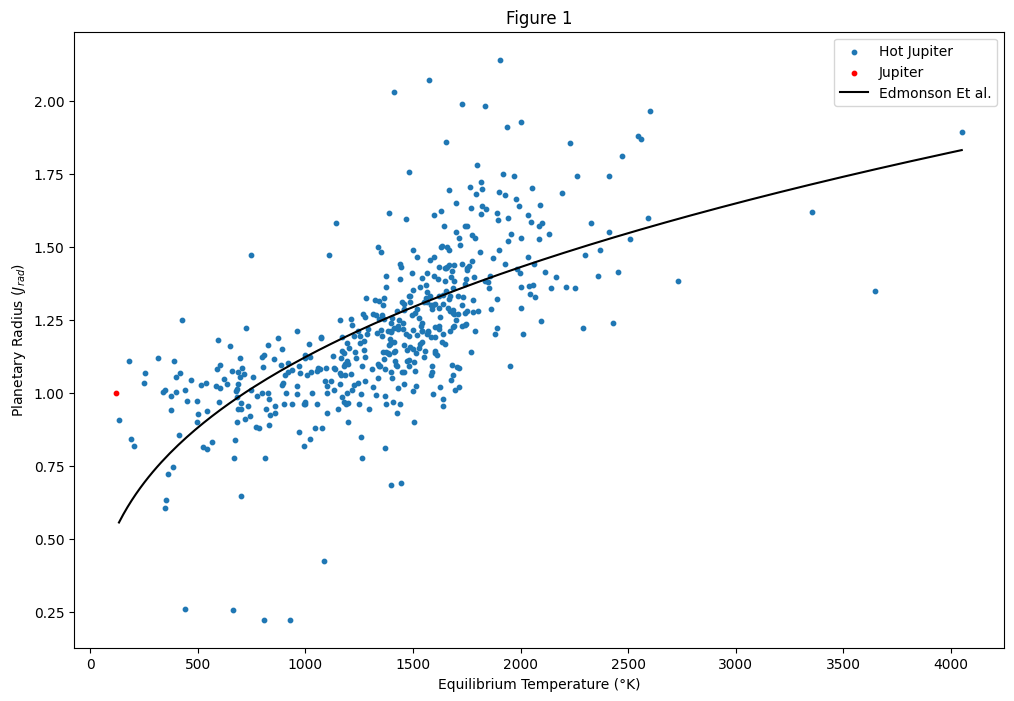

In [62]:
plot_legend(temps, radii, "Equilibrium Temperature (°K)", "Planetary Radius ($J_{rad}$)", 1)

How does the degree of inflation depend on incident flux?

In [63]:
def base_plot(xaxis, yaxis, xname, yname, a):
    plt.figure(figsize=(12,8))
    plt.scatter(xaxis, yaxis, s=10)

    plt.xlabel(xname)
    plt.ylabel(yname)
    plt.title(f"Figure {a}")

    plt.show()


<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\macau\AppData\Local\Temp\ipykernel_5796\479657048.py:1: SyntaxWarning: invalid escape sequence '\c'
  base_plot(fluxes, increase_cents, "Incidence Flux ($erg \cdot cm^{-2} \cdot s^{-1}$)", "Degree of Inflation from Expected Value (%)", 2)


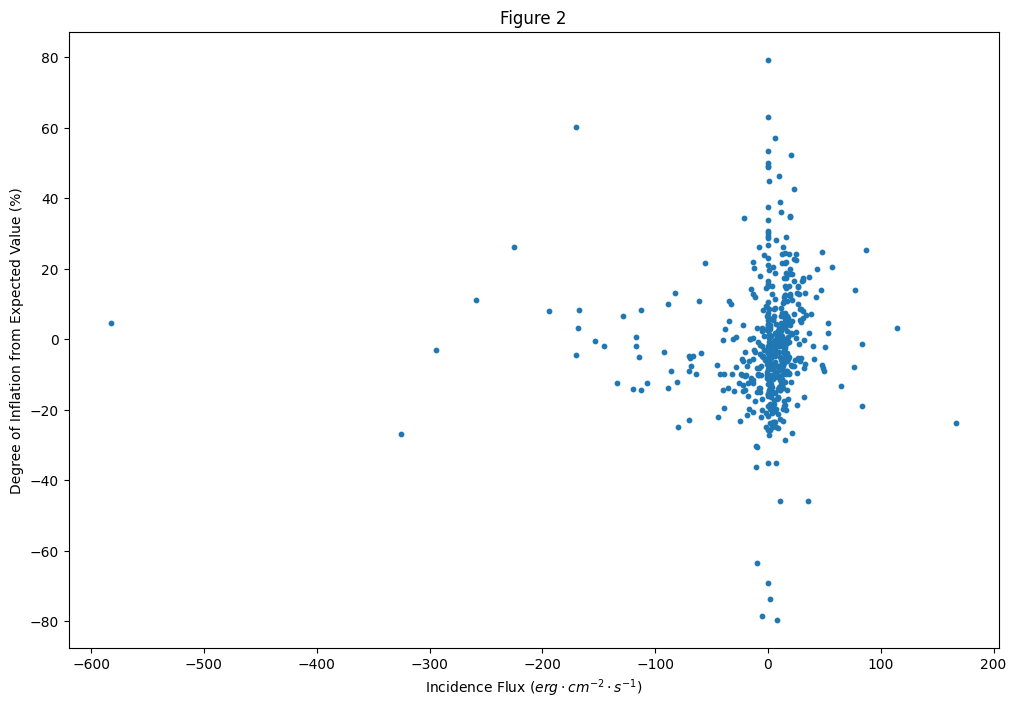

In [ ]:
base_plot(fluxes, percentage_increase, "Incidence Flux ($erg \cdot cm^{-2} \cdot s^{-1}$)", "Degree of Inflation from Expected Value (%)", 2)

Are there correlations with host star properties such as mass or metallicity?

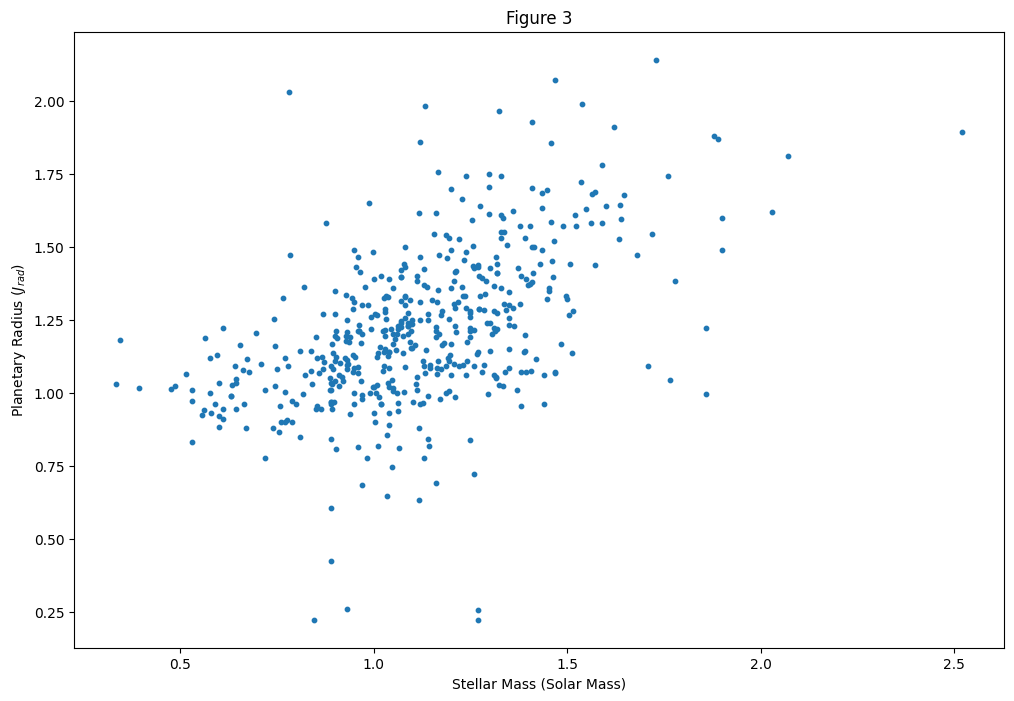

In [65]:
base_plot(st_masses, radii, "Stellar Mass (Solar Mass)", "Planetary Radius ($J_{rad}$)", 3)

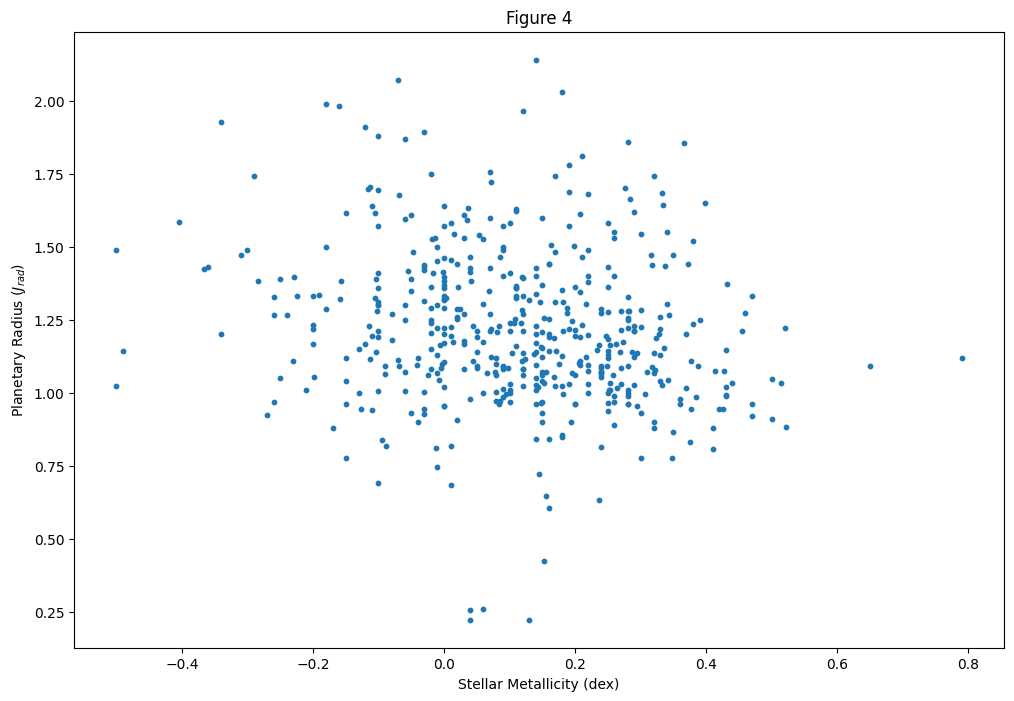

In [66]:
base_plot(st_mets, radii, "Stellar Metallicity (dex)", "Planetary Radius ($J_{rad}$)", 4)

How large are the observational uncertainties, and how do they affect your conclusions?

In [68]:
def error_plot(xaxis, yaxis, xname, yname, xerr, yerr, n):
    plt.figure(figsize=(12,8))
    plt.errorbar(x=xaxis, y=yaxis,
                 xerr=xerr, yerr=yerr,
                 fmt="o", markersize=4, capsize=3)

    plt.xlabel(xname)
    plt.ylabel(yname)
    plt.title(f"Figure {n}")

    plt.show()

In [55]:
terr = [temps_minus, temps_plus]
prerr = [radii_minus, radii_plus]


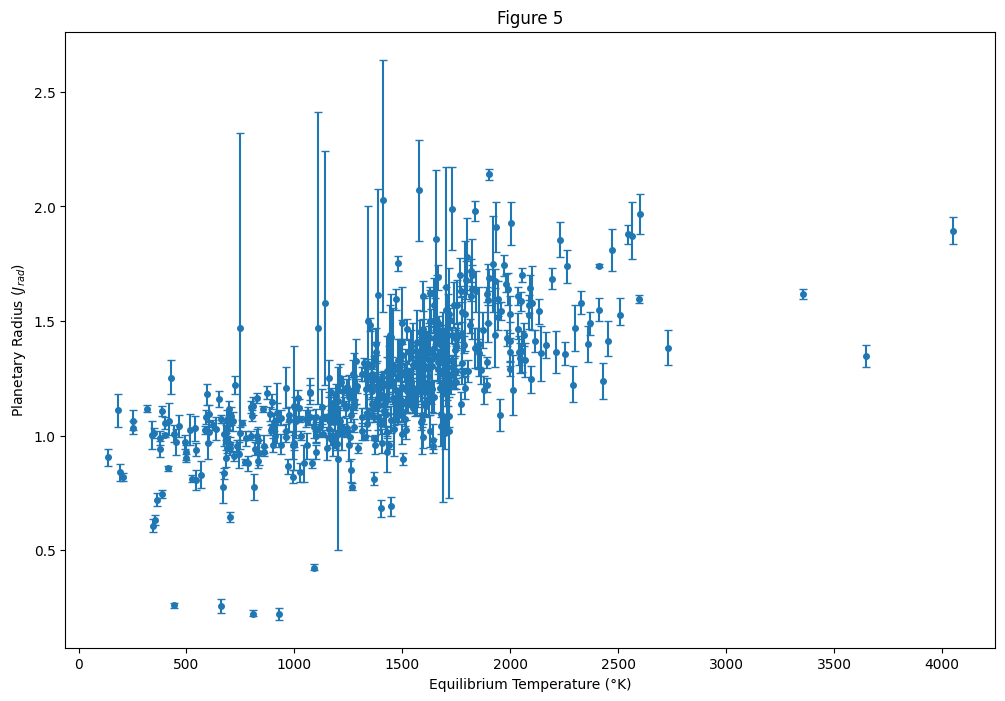

In [69]:
error_plot(temps, radii, "Equilibrium Temperature (°K)", "Planetary Radius ($J_{rad}$)", None, prerr, 5)

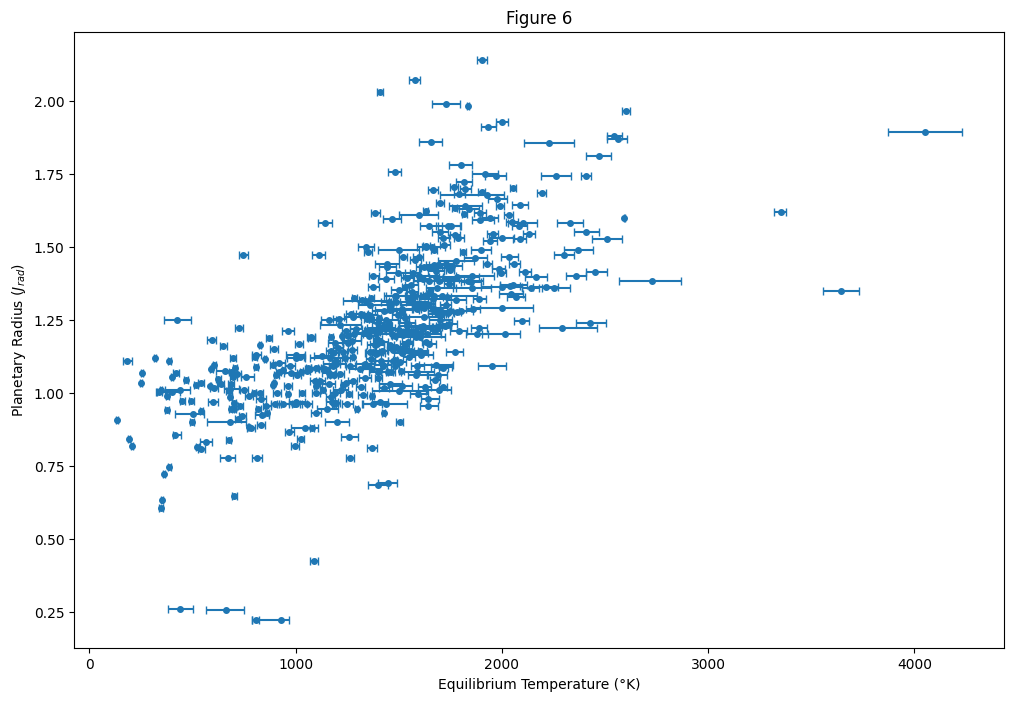

In [70]:
error_plot(temps, radii, "Equilibrium Temperature (°K)", "Planetary Radius ($J_{rad}$)", terr, None, 6)

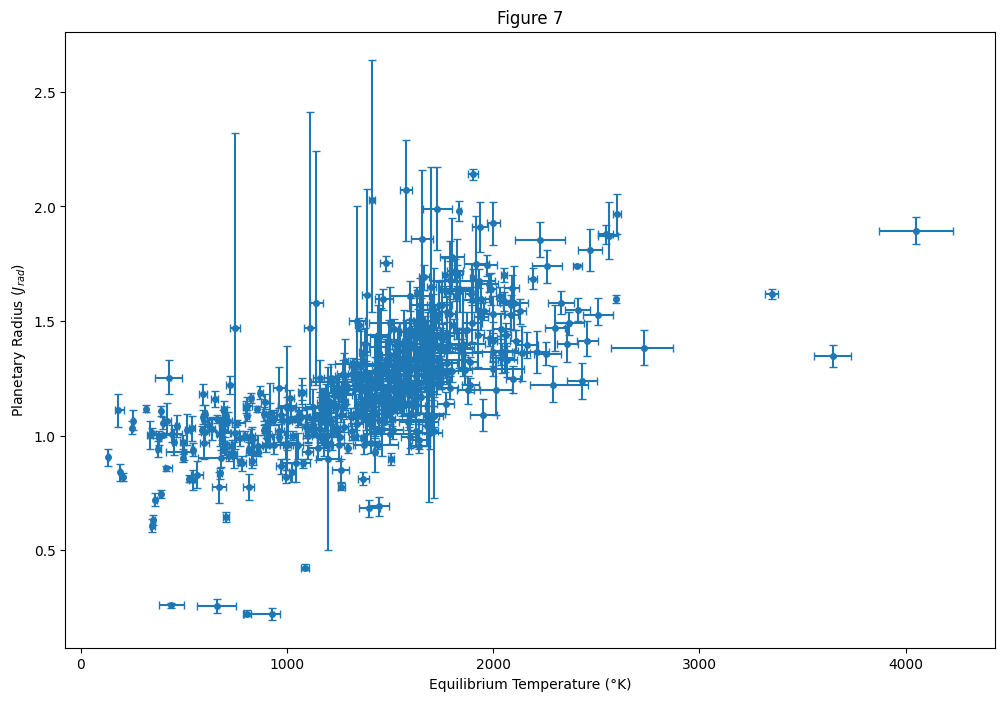

In [71]:
error_plot(temps, radii, "Equilibrium Temperature (°K)", "Planetary Radius ($J_{rad}$)", terr, prerr, 7)

In [72]:
def legend_error_plot(xaxis, yaxis, xname, yname, xerr, yerr, n):
    plt.figure(figsize=(12,8))
    plt.errorbar(x=xaxis, y=yaxis,
                 xerr=xerr, yerr=yerr,
                 fmt="o", markersize=4, capsize=3, label="Hot Jupiter")

    plt.scatter(J_temp, J_rad, color="red", s=10, label="Jupiter")

    x = np.linspace(min(xaxis), max(xaxis), 200)
    y = (1.1 * x ** 0.35) / 11
    plt.plot(x, y, linestyle="-", color="black", label="Edmonson Et al.")

    plt.xlabel(xname)
    plt.ylabel(yname)
    plt.title(f"Figure {n}")

    plt.legend()
    plt.show()

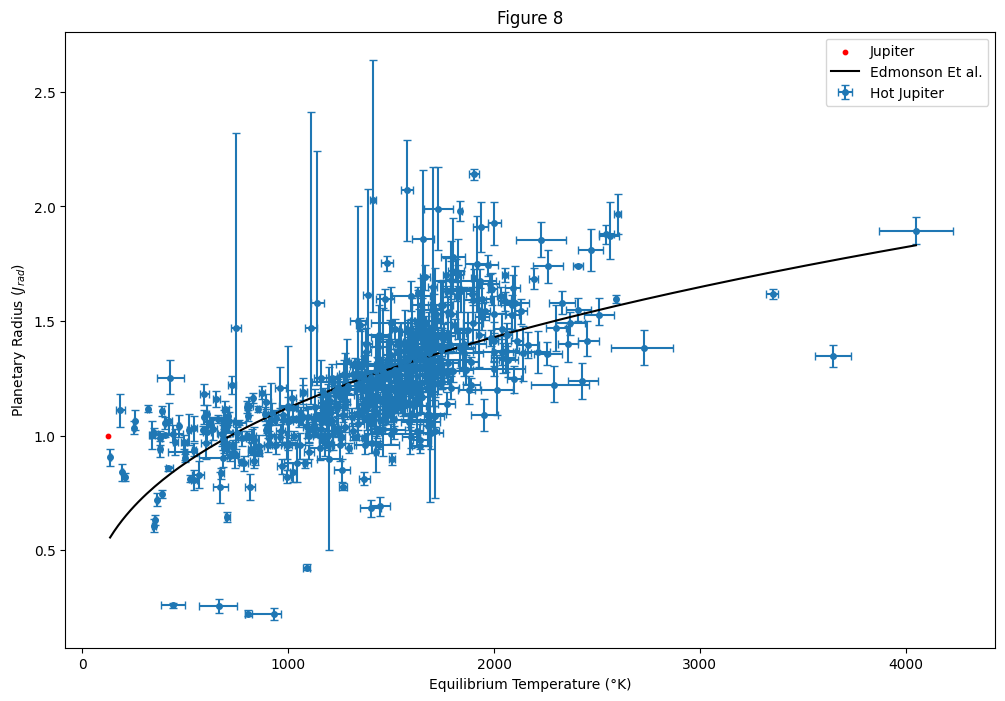

In [73]:
legend_error_plot(temps, radii, "Equilibrium Temperature (°K)", "Planetary Radius ($J_{rad}$)", terr, prerr, 8)

Compare your results to simple theoretical expectations for gas giant structure. What do your findings suggest about the physical processes operating in these atmospheres?